# Project 2: Outlier Detection
### Aleksandra Idczak
This notebook contains plots, and data aggregation utilized in the report. The analysis, conclusions, reasoning is in the report. I know that later you stated that you prefer a full jupyter notebook with markdown comments, however I did the project pretty early and didn't want to change everything. I hope you understand.

The logic behind evaluation is in the file `utils.py`, so that is notebook is cleaner.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import scipy.io
import deadwood
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from utils import evaluate, plot_2dim, estimate_contamination_iqr
import matplotlib.pyplot as plt
import seaborn as sns

## Evaluation on Outlier Detection DataSets
don't run - takes time and requires data in folder `data`

In [ ]:
data_dir = Path("../data")
dataset_names = [
    "annthyroid",
    "arrhythmia",
    "breastw",
    "cardio",
    "glass",
    "letter",
    "lympho",
    "mammography",
    "musk",
    "pendigits",
    "satellite",
    "satimage-2",
    "shuttle",
    "speech",
    "thyroid",
    "vertebral",
    "vowels",
    "wine",
]
scaler = RobustScaler()
all_results = []
for dataset in dataset_names:
    path = data_dir / f"{dataset}.mat"
    mat = scipy.io.loadmat(path)
    X = mat.get("X")
    y = mat.get("y")
    X = pd.DataFrame(X)
    y = pd.Series(y.flatten(), name="y")
    data = pd.concat([X, y], axis=1)
    data.drop_duplicates(inplace=True)
    X = data.drop(columns=["y"])
    y = data["y"]
    n = X.shape[0]
    p = X.shape[1]
    X = scaler.fit_transform(X)
    res = evaluate(X, y, dataset, n, p)
    all_results.append(res)

res = pd.concat(all_results, ignore_index=True)
res.to_csv("results_part2.csv", index=False)
res

## Evaluation on 2 dimensional datasets
don't run - takes time and requires data in folder `data`

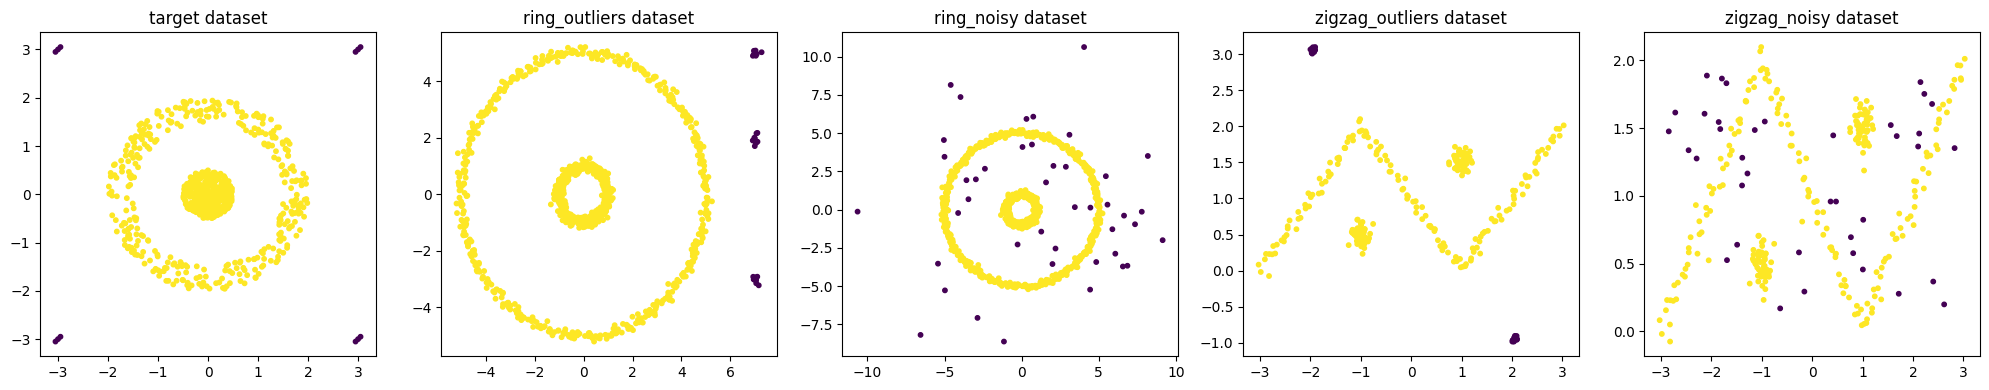

In [3]:
dataset_names = [
    "target",
    "ring_outliers",
    "ring_noisy",
    "zigzag_outliers",
    "zigzag_noisy",
]
data_dir = Path("../data/2dim")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    X = np.loadtxt(data_dir / f"{dataset_names[i]}.data.gz", ndmin=2)
    y = np.loadtxt(data_dir / f"{dataset_names[i]}.labels0.gz", dtype="int")
    y = (y == 0).astype(int)
    axes[i].scatter(X[:, 0], X[:, 1], c=1 - y, cmap="viridis", s=10)
    axes[i].set_title(f"{dataset_names[i]} dataset")

plt.tight_layout()

In [ ]:
data_dir = Path("../data/2dim")
dataset_names = [
    "ring_outliers",
    "target",
    "zigzag_outliers",
    "ring_noisy",
    "zigzag_noisy",
]
scaler = RobustScaler()
all_results = []
for dataset in dataset_names:
    X = np.loadtxt(data_dir / f"{dataset}.data.gz", ndmin=2)
    y = np.loadtxt(data_dir / f"{dataset}.labels0.gz", dtype="int")
    y = (y == 0).astype(int)
    X = pd.DataFrame(X)
    y = pd.Series(y.flatten(), name="y")
    data = pd.concat([X, y], axis=1)
    data.drop_duplicates(inplace=True)
    X = data.drop(columns=["y"])
    y = data["y"]
    n = X.shape[0]
    p = X.shape[1]
    X = scaler.fit_transform(X)
    res = evaluate(X, y, False, dataset, n, p)
    all_results.append(res)

res = pd.concat(all_results, ignore_index=True)
res.to_csv("results_2dim.csv", index=False)

### Best predictions (according to custom score) visualized 

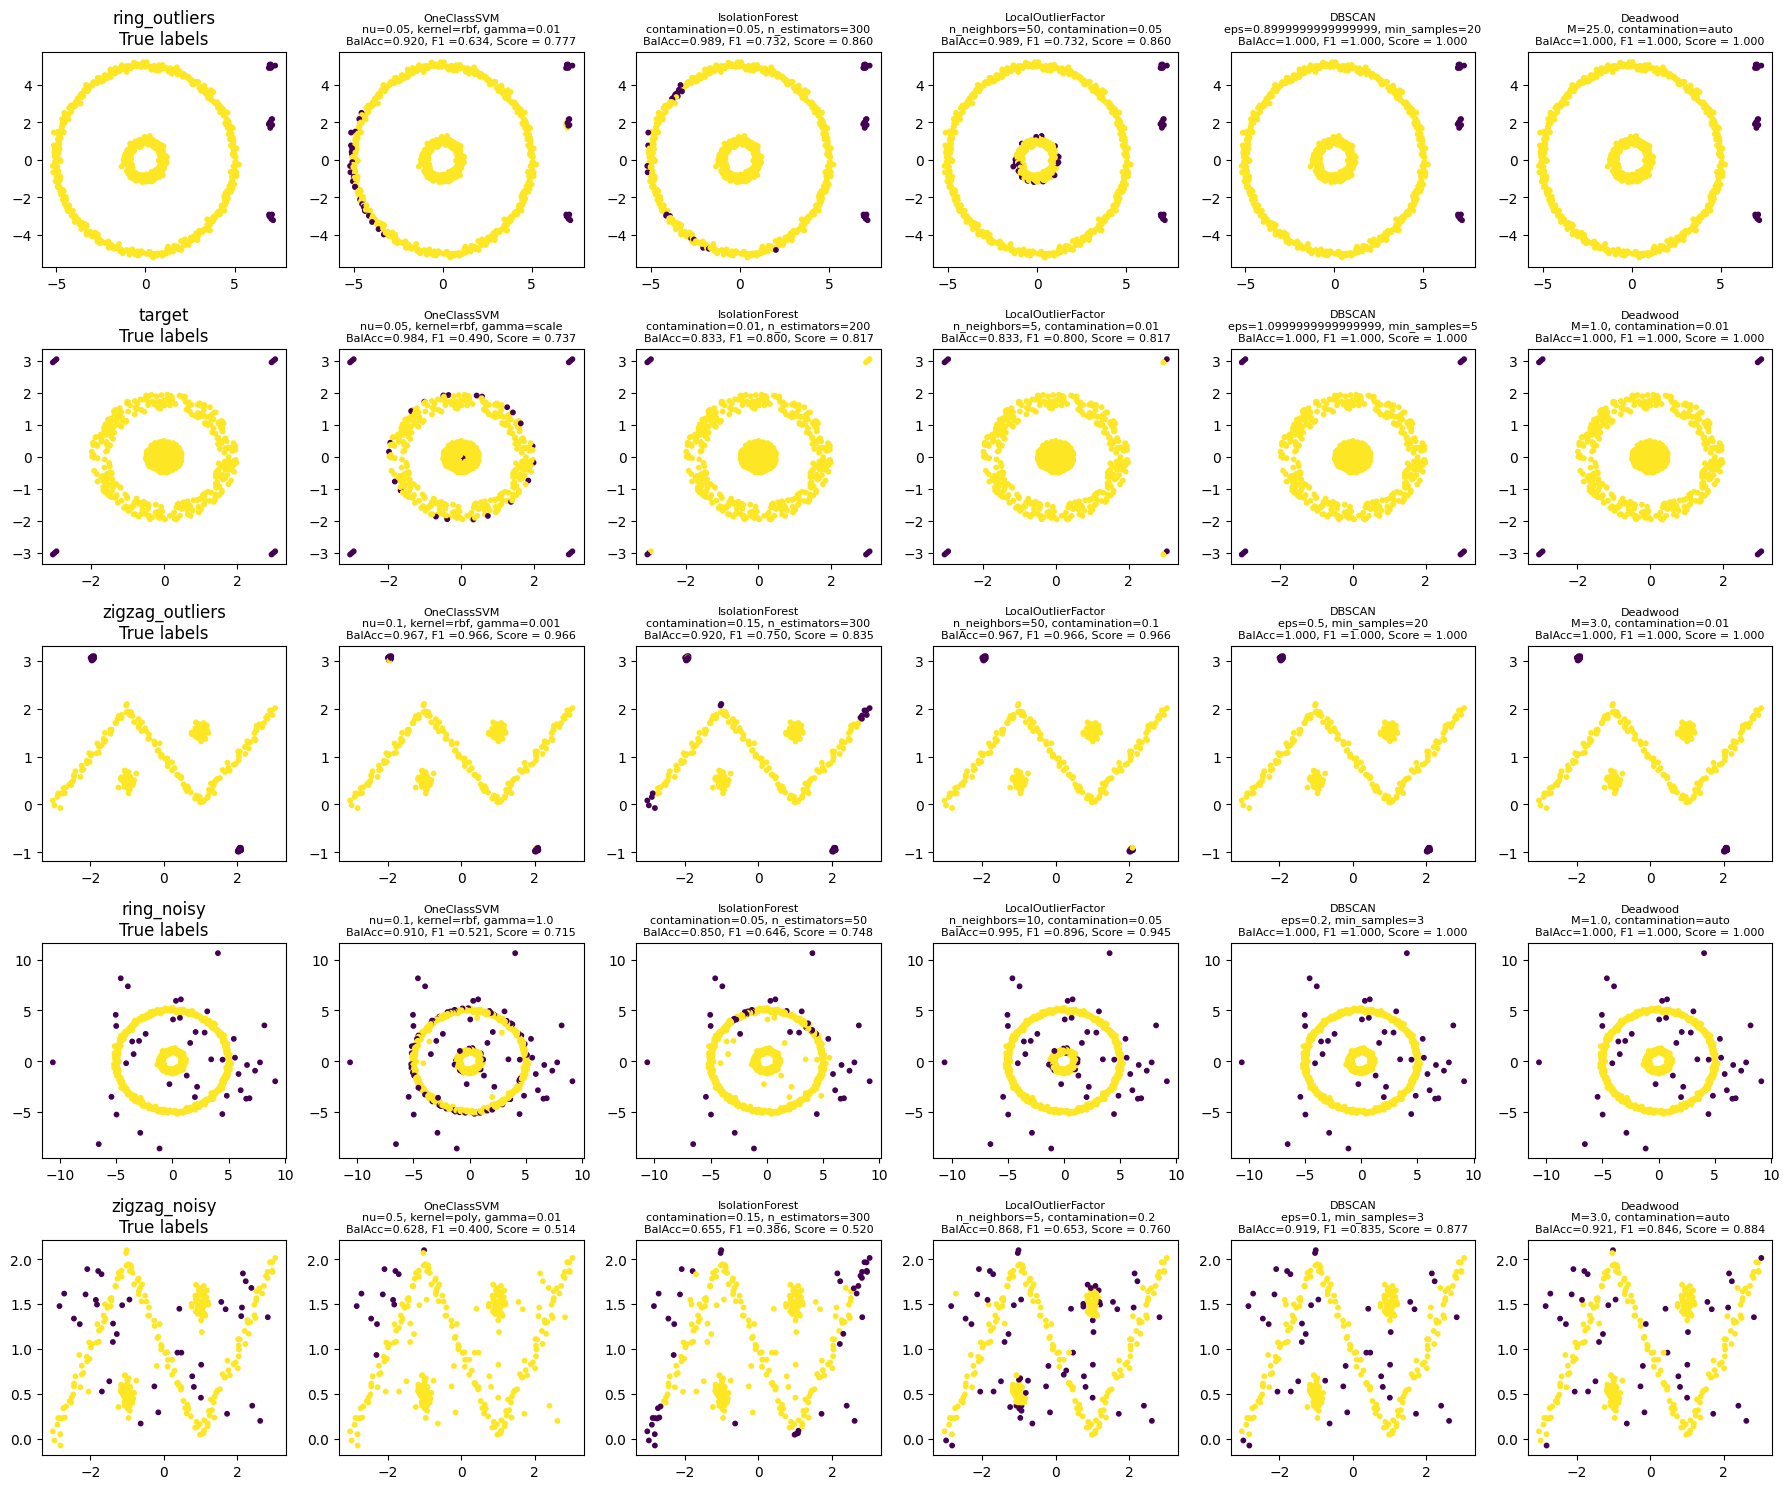

In [4]:
data_dir = Path("../data/2dim")
dataset_names = [
    "ring_outliers",
    "target",
    "zigzag_outliers",
    "ring_noisy",
    "zigzag_noisy",
]
plot_2dim(dataset_names, data_dir)

## Analysis

In [5]:
res = pd.read_csv("results_full.csv")
p, r = res["Precision"], res["Recall"]
res["F1"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
res["Score"] = (res["F1"] + res["BalAcc"]) / 2

ocsvm = res[res["model"] == "OneClassSVM"][
    [
        "dataset",
        "n",
        "p",
        "nu",
        "kernel",
        "gamma",
        "Score",
        "BalAcc",
        "F1",
        "failure",
    ]
]
iforest = res[res["model"] == "IsolationForest"][
    [
        "dataset",
        "n",
        "p",
        "contamination",
        "n_estimators",
        "Score",
        "BalAcc",
        "F1",
        "failure",
    ]
]
lof = res[res["model"] == "LocalOutlierFactor"][
    [
        "dataset",
        "n",
        "p",
        "n_neighbors",
        "contamination",
        "Score",
        "BalAcc",
        "F1",
        "failure",
    ]
]
dbscan = res[res["model"] == "DBSCAN"][
    [
        "dataset",
        "n",
        "p",
        "eps",
        "min_samples",
        "Score",
        "BalAcc",
        "F1",
        "failure",
    ]
]
dw = res[res["model"] == "Deadwood"][
    [
        "dataset",
        "n",
        "p",
        "M",
        "contamination",
        "Score",
        "BalAcc",
        "F1",
        "failure",
    ]
]

### One Class SVM

#### Balanced Accuracy

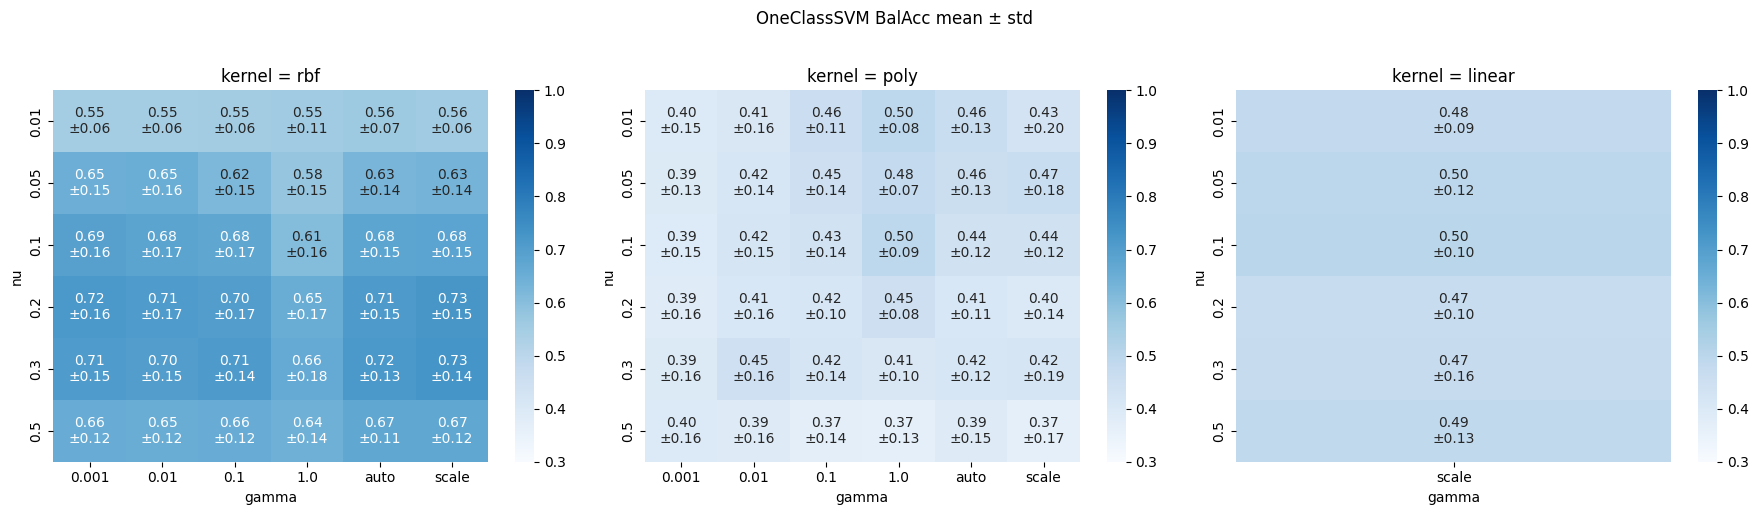

In [6]:
kernels = ["rbf", "poly", "linear"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, kernels):
    subset = ocsvm[ocsvm["kernel"] == kernel]

    mean_pivot = subset.pivot_table(
        index="nu", columns="gamma", values="BalAcc", aggfunc="mean"
    )
    std_pivot = subset.pivot_table(
        index="nu", columns="gamma", values="BalAcc", aggfunc="std"
    )

    labels = (
        mean_pivot.map(lambda x: f"{x:.2f}")
        + "\n±"
        + std_pivot.map(lambda x: f"{x:.2f}")
    )

    sns.heatmap(
        mean_pivot,
        annot=labels,
        fmt="",
        cmap="Blues",
        vmin=0.3,
        vmax=1,
        ax=ax,
    )
    ax.set_title(f"kernel = {kernel}")

plt.suptitle("OneClassSVM BalAcc mean ± std", y=1.02)
plt.tight_layout()
plt.show()

#### Score

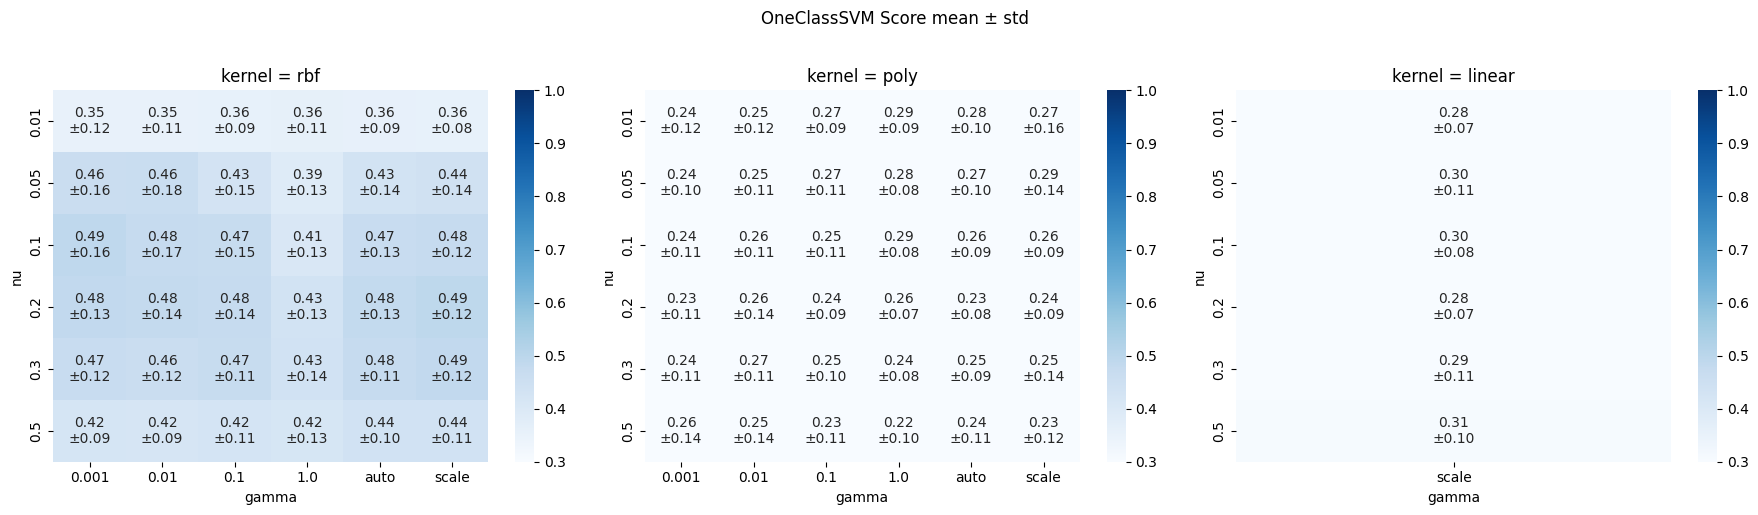

In [7]:
kernels = ["rbf", "poly", "linear"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, kernels):
    subset = ocsvm[ocsvm["kernel"] == kernel]

    mean_pivot = subset.pivot_table(
        index="nu", columns="gamma", values="Score", aggfunc="mean"
    )
    std_pivot = subset.pivot_table(
        index="nu", columns="gamma", values="Score", aggfunc="std"
    )

    labels = (
        mean_pivot.map(lambda x: f"{x:.2f}")
        + "\n±"
        + std_pivot.map(lambda x: f"{x:.2f}")
    )

    sns.heatmap(
        mean_pivot,
        annot=labels,
        fmt="",
        cmap="Blues",
        vmin=0.3,
        vmax=1,
        ax=ax,
    )
    ax.set_title(f"kernel = {kernel}")

plt.suptitle("OneClassSVM Score mean ± std", y=1.02)
plt.tight_layout()
plt.show()

### DBSCAN

#### Balanced Accuracy

Text(0.5, 1.0, 'DBSCAN BalAcc mean ± std')

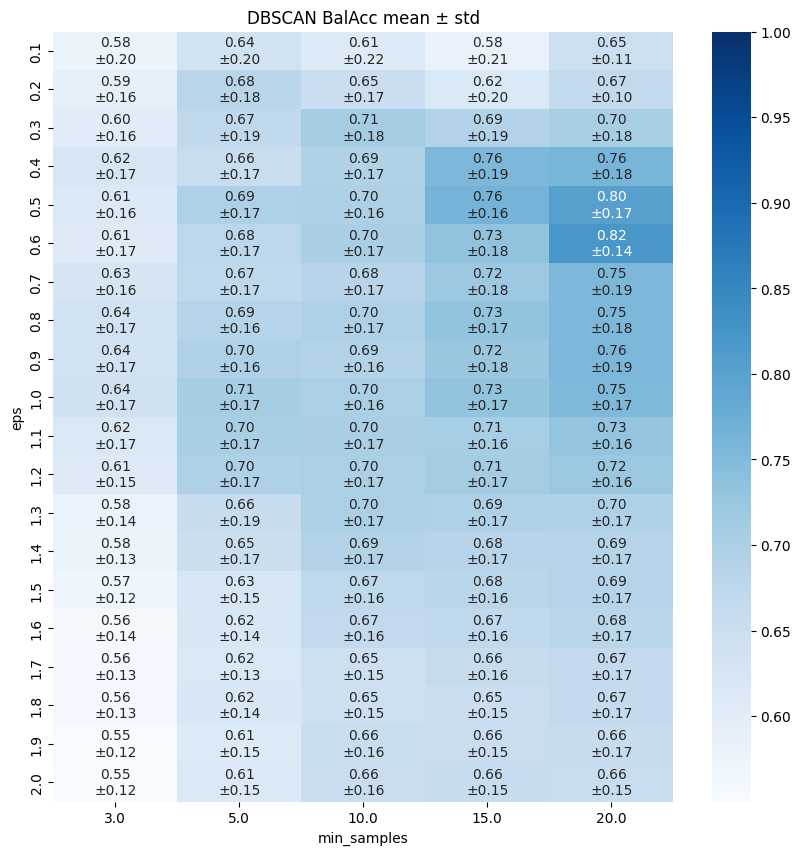

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
dbscan["eps"] = dbscan["eps"].round(2)
mean_pivot = dbscan.pivot_table(
    index="eps", columns="min_samples", values="BalAcc", aggfunc="mean"
)
std_pivot = dbscan.pivot_table(
    index="eps", columns="min_samples", values="BalAcc", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("DBSCAN BalAcc mean ± std")

#### Score

Text(0.5, 1.0, 'DBSCAN Score mean ± std')

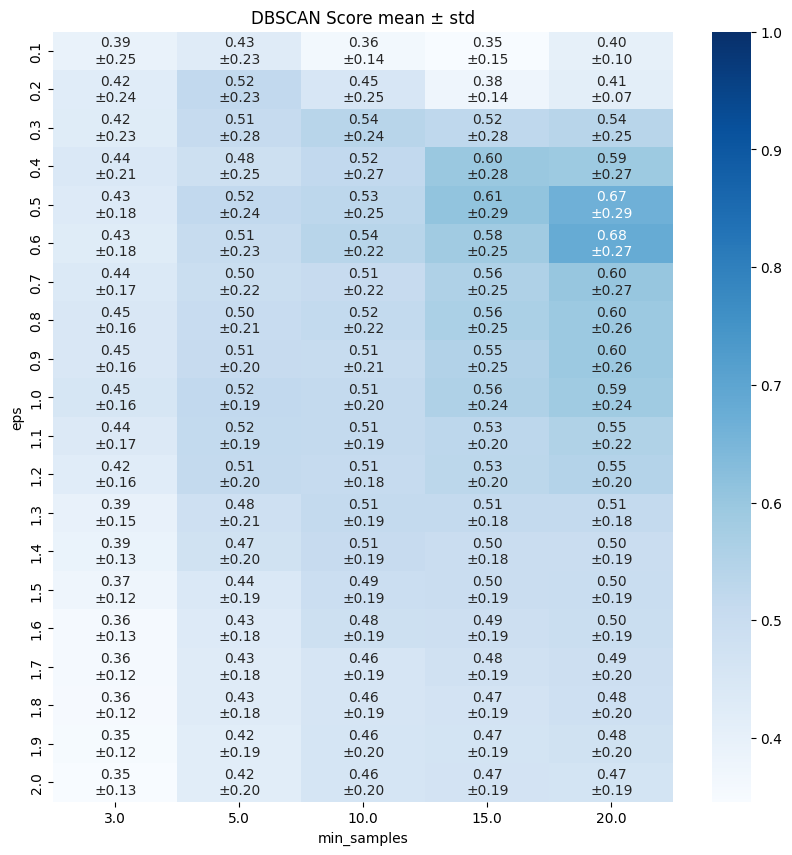

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
dbscan["eps"] = dbscan["eps"].round(2)
mean_pivot = dbscan.pivot_table(
    index="eps", columns="min_samples", values="Score", aggfunc="mean"
)
std_pivot = dbscan.pivot_table(
    index="eps", columns="min_samples", values="Score", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("DBSCAN Score mean ± std")

### Isolation Forest

#### Balanced Accuracy

Text(0.5, 1.0, 'IsolationForest mean BalAcc ± std')

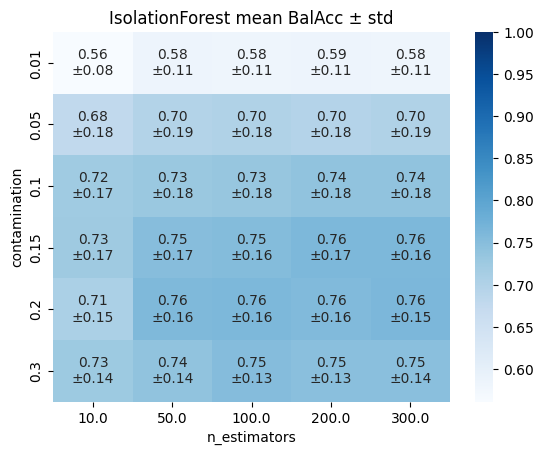

In [10]:
mean_pivot = iforest.pivot_table(
    index="contamination", columns="n_estimators", values="BalAcc", aggfunc="mean"
)
std_pivot = iforest.pivot_table(
    index="contamination", columns="n_estimators", values="BalAcc", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("IsolationForest mean BalAcc ± std")

#### Score

Text(0.5, 1.0, 'IsolationForest Score mean ± std')

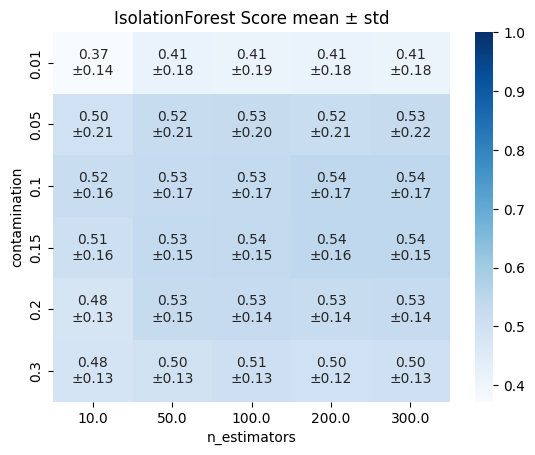

In [11]:
mean_pivot = iforest.pivot_table(
    index="contamination", columns="n_estimators", values="Score", aggfunc="mean"
)
std_pivot = iforest.pivot_table(
    index="contamination", columns="n_estimators", values="Score", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("IsolationForest Score mean ± std")

### Local Outlier Factor 

#### Balanced Accuracy

Text(0.5, 1.0, 'LocalOutlierFactor mean BalAcc ± std')

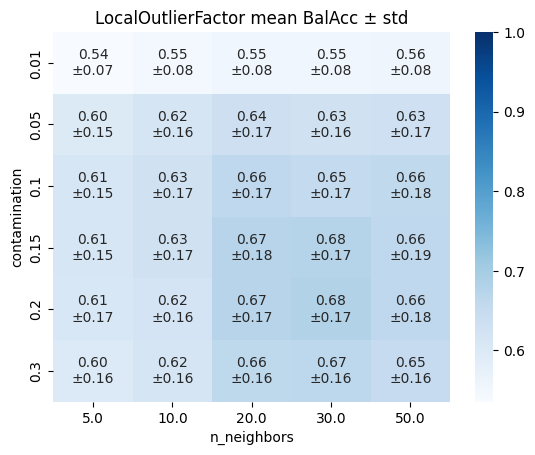

In [12]:
mean_pivot = lof.pivot_table(
    index="contamination", columns="n_neighbors", values="BalAcc", aggfunc="mean"
)
std_pivot = lof.pivot_table(
    index="contamination", columns="n_neighbors", values="BalAcc", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("LocalOutlierFactor mean BalAcc ± std")

#### Score

Text(0.5, 1.0, 'LocalOutlierFactor Score mean ± std')

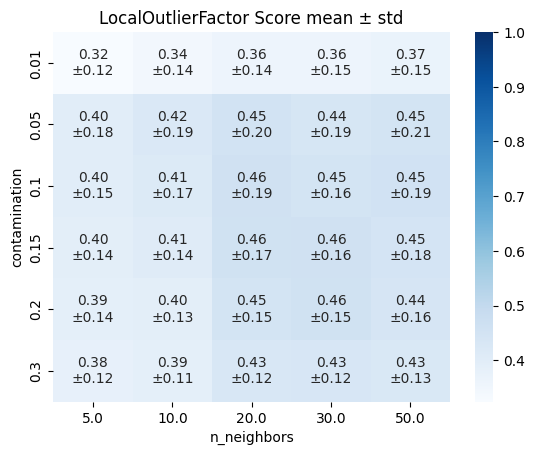

In [13]:
mean_pivot = lof.pivot_table(
    index="contamination", columns="n_neighbors", values="Score", aggfunc="mean"
)
std_pivot = lof.pivot_table(
    index="contamination", columns="n_neighbors", values="Score", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("LocalOutlierFactor Score mean ± std")

### Deadwood

#### Balanced Accuracy

Text(0.5, 1.0, 'Deadwood mean BalAcc ± std')

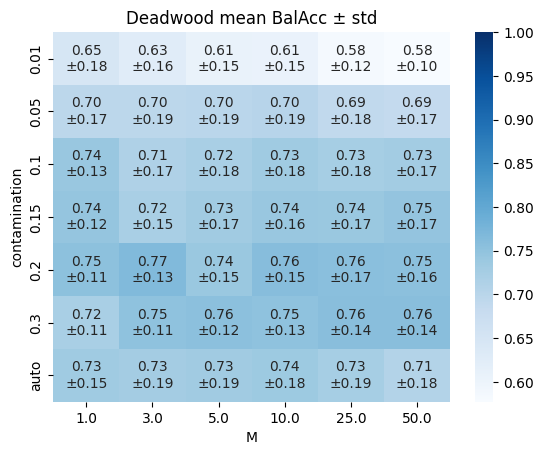

In [14]:
mean_pivot = dw.pivot_table(
    index="contamination", columns="M", values="BalAcc", aggfunc="mean"
)
std_pivot = dw.pivot_table(
    index="contamination", columns="M", values="BalAcc", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("Deadwood mean BalAcc ± std")

#### Score

Text(0.5, 1.0, 'Deadwood Score mean ± std')

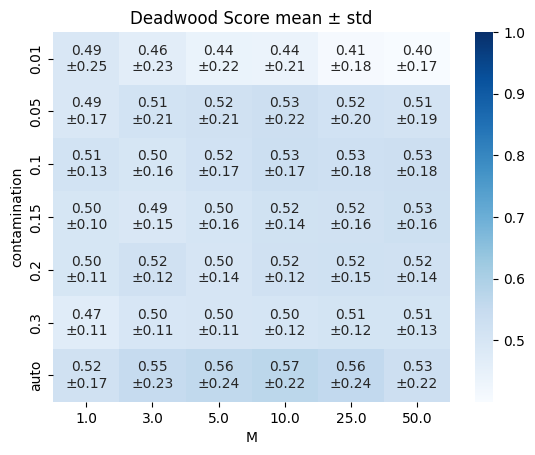

In [15]:
mean_pivot = dw.pivot_table(
    index="contamination", columns="M", values="Score", aggfunc="mean"
)
std_pivot = dw.pivot_table(
    index="contamination", columns="M", values="Score", aggfunc="std"
)

labels = (
    mean_pivot.map(lambda x: f"{x:.2f}") + "\n±" + std_pivot.map(lambda x: f"{x:.2f}")
)

sns.heatmap(
    mean_pivot,
    annot=labels,
    fmt="",
    cmap="Blues",
    # vmin=0.3,
    vmax=1,
)
plt.title("Deadwood Score mean ± std")

### Ranking of methods based on score

In [16]:
df = pd.read_csv("results_full.csv")
p, r = df["Precision"], df["Recall"]
df["F1"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)

# score = average of F1 and Balanced Accuracy
df["Score"] = (df["F1"] + df["BalAcc"]) / 2

# failure = score 0
fail_mask = df["failure"].astype(bool) if df["failure"].dtype != bool else df["failure"]
df.loc[fail_mask, ["F1", "BalAcc", "Score"]] = 0.0

# global ranking by model
global_ranking = (
    df.groupby("model")
    .agg(
        mean_score=("Score", "mean"),
        median_score=("Score", "median"),
        mean_F1=("F1", "mean"),
        mean_BalAcc=("BalAcc", "mean"),
        failure_rate=("failure", "mean"),
    )
    .sort_values("mean_score", ascending=False)
)
print("Global ranking (averaged over all runs)")
global_ranking.round(3)

Global ranking (averaged over all runs)


,mean_score,median_score,mean_F1,mean_BalAcc,failure_rate
model,,,,,
Deadwood,0.507,0.508,0.299,0.714,0.000
IsolationForest,0.501,0.508,0.294,0.708,0.000
LocalOutlierFactor,0.415,0.353,0.204,0.626,0.000
OneClassSVM,0.343,0.328,0.151,0.536,0.001
DBSCAN,0.295,0.313,0.183,0.408,0.387


### Number of wins per model
win = best score on dataset

In [17]:
winners = (
    df.loc[df.groupby("dataset")["Score"].idxmax()]
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)
print("Win counts per model")
winners["model"].value_counts()

Win counts per model


model
IsolationForest       9
DBSCAN                8
Deadwood              4
LocalOutlierFactor    1
OneClassSVM           1
Name: count, dtype: int64

### Distribution of scores per algorithm

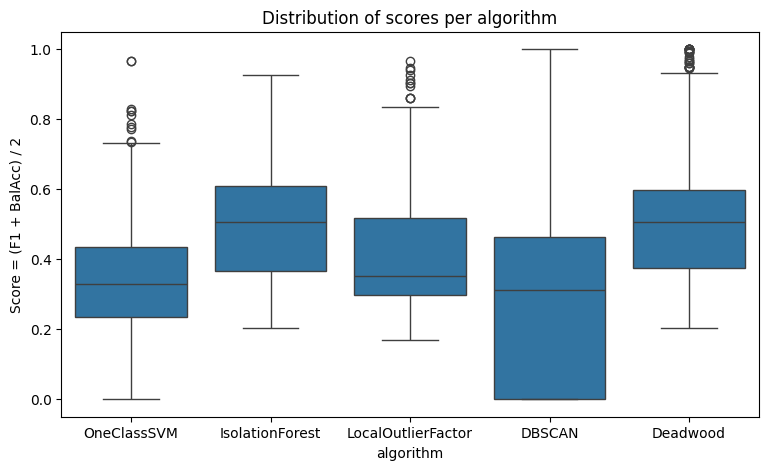

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="model", y="Score", legend="full")
ax.set_ylabel("Score = (F1 + BalAcc) / 2")
ax.set_xlabel("algorithm")
ax.set_title("Distribution of scores per algorithm")
plt.show()

### Impact of n (samples) and p (predictors)

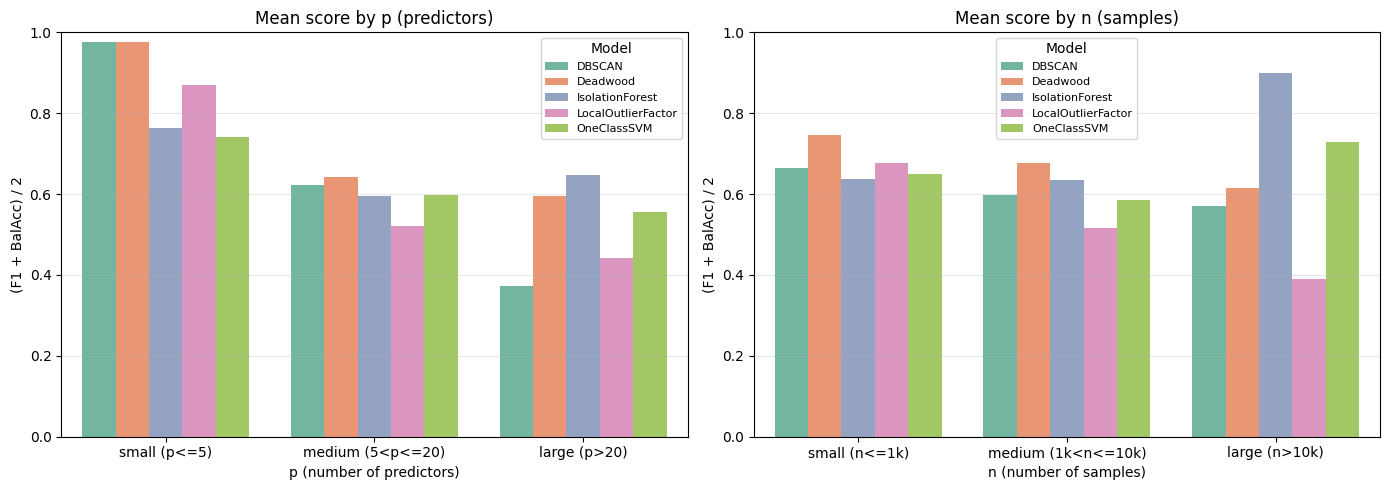

In [19]:
bpm = df.loc[df.groupby(["model", "dataset"])["Score"].idxmax()].reset_index(drop=True)

models = sorted(bpm["model"].unique())

# bins
bpm["p_bin"] = pd.cut(
    bpm["p"],
    bins=[0, 5, 20, np.inf],
    labels=["small (p<=5)", "medium (5<p<=20)", "large (p>20)"],
)

bpm["n_bin"] = pd.cut(
    bpm["n"],
    bins=[0, 1000, 10000, np.inf],
    labels=["small (n<=1k)", "medium (1k<n<=10k)", "large (n>10k)"],
)

df_p = bpm.groupby(["p_bin", "model"], observed=True)["Score"].mean().reset_index()

df_n = bpm.groupby(["n_bin", "model"], observed=True)["Score"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_p, x="p_bin", y="Score", hue="model", ax=axes[0], palette="Set2")

axes[0].set_title("Mean score by p (predictors)")
axes[0].set_ylabel("(F1 + BalAcc) / 2")
axes[0].set_xlabel("p (number of predictors)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x")
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend(title="Model", fontsize=8)

sns.barplot(data=df_n, x="n_bin", y="Score", hue="model", ax=axes[1], palette="Set2")

axes[1].set_title("Mean score by n (samples)")
axes[1].set_ylabel("(F1 + BalAcc) / 2")
axes[1].set_xlabel("n (number of samples)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x")
axes[1].grid(alpha=0.3, axis="y")
axes[1].legend(title="Model", fontsize=8)

plt.tight_layout()
plt.show()

## Test data

### Small EDA

In [20]:
X = pd.read_csv("test_data.csv").iloc[:, 1:]
X.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21
count,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,...,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000,3443.000000
mean,0.021995,0.258269,0.513854,0.757868,0.993694,1.741696,2.481298,2.716913,2.966184,3.439649,...,3.469393,2.996764,2.748678,2.517766,1.808571,1.041751,0.791173,0.518289,0.284214,-0.013369
std,1.019034,1.058559,1.171816,1.404026,1.659791,1.793667,2.009972,1.757142,1.641388,1.467588,...,1.450349,1.607728,1.750343,1.997571,1.791992,1.642561,1.405260,1.199471,1.071377,0.991221
min,-2.950000,-3.250000,-4.200000,-3.840000,-3.480000,-2.760000,-3.320000,-3.520000,-3.380000,-1.770000,...,-1.610000,-2.610000,-2.370000,-2.480000,-2.990000,-3.560000,-3.190000,-3.500000,-3.570000,-3.460000
25%,-0.660000,-0.460000,-0.280000,-0.260000,-0.210000,0.360000,0.930000,1.460000,1.830000,2.470000,...,2.490000,1.880000,1.450000,1.015000,0.490000,-0.180000,-0.210000,-0.330000,-0.430000,-0.660000
50%,0.020000,0.270000,0.470000,0.650000,0.700000,1.490000,2.280000,2.810000,3.180000,3.500000,...,3.560000,3.230000,2.820000,2.310000,1.560000,0.810000,0.660000,0.480000,0.270000,-0.020000
75%,0.710000,0.980000,1.270000,1.670000,2.070000,2.990000,3.970000,3.990000,4.190000,4.470000,...,4.480000,4.180000,4.070000,4.010000,3.050000,2.170000,1.770000,1.330000,1.010000,0.670000
max,3.940000,3.830000,4.390000,5.750000,6.500000,7.040000,8.760000,7.840000,7.900000,7.630000,...,7.400000,7.500000,7.750000,8.720000,7.550000,6.710000,5.560000,5.280000,4.650000,4.010000


X shape: n = 3443, p = 21, n/p=163.95238095238096
Number of duplicates: 0
IQR contamination estimation: 7.14% 
Correlation matrix


<Axes: >

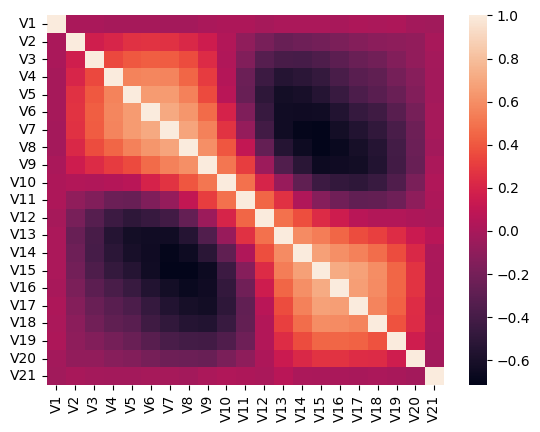

In [21]:
X = pd.read_csv("test_data.csv").iloc[:, 1:]
n, p = X.shape
print(f"X shape: n = {n}, p = {p}, n/p={n/p}")
X.drop_duplicates(inplace=True)
print(f"Number of duplicates: {n - X.shape[0]}")
cont = estimate_contamination_iqr(X, k=1.5)
print(f"IQR contamination estimation: {cont*100:.2f}% ")
print("Correlation matrix")
corr = X.corr()
sns.heatmap(corr)

Datasets that are kind of similar to test data in terms of p or n 
- cardio, n=1822, p=21, n/p = 86.76
- satellite, n=6435, p=36, n/p = 178.75
- satimage-2, n=5801, p=36, n/p = 161.14
- vowels, n=1452, p=12, n/p = 121.0
- speech, n=3686, p=400, n/p = 9.215
- thyroid, n=3656, p=6, n/p = 609.33

I think that cardio maybe the most comparable, it has 9.6% outliers. Maybe vowels is also worth checking, it has 3.4% outliers. I will use methods and hyperparameters that perform well on those two datasets.

In [22]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

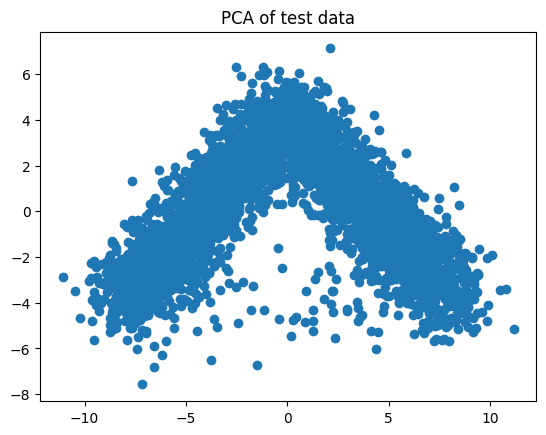

In [23]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.title("PCA of test data")
plt.show()

### Choosing models

In [24]:
data_dir = Path("../data")
dataset_names = [
    "cardio",
    "vowels",
]
scaler = RobustScaler()
all_results = []
for dataset in dataset_names:
    path = data_dir / f"{dataset}.mat"
    mat = scipy.io.loadmat(path)
    X = mat.get("X")
    y = mat.get("y")
    X = pd.DataFrame(X)
    y = pd.Series(y.flatten(), name="y")
    data = pd.concat([X, y], axis=1)
    data.drop_duplicates(inplace=True)
    X = data.drop(columns=["y"])
    y = data["y"]
    n = X.shape[0]
    p = X.shape[1]
    X = scaler.fit_transform(X)
    res = evaluate(X, y, False, dataset, n, p)
    all_results.append(res)

res = pd.concat(all_results, ignore_index=True)
res

,dataset,n,p,model,nu,kernel,gamma,AUC,Accuracy,Precision,Recall,BalAcc,failure,contamination,n_estimators,n_neighbors,eps,min_samples,M
0,cardio,1822,21,OneClassSVM,0.01,rbf,scale,0.524928,0.902854,0.454545,0.057143,0.524928,False,NaN,NaN,NaN,NaN,NaN,NaN
1,cardio,1822,21,OneClassSVM,0.01,rbf,auto,0.555464,0.884193,0.295455,0.148571,0.555464,False,NaN,NaN,NaN,NaN,NaN,NaN
2,cardio,1822,21,OneClassSVM,0.01,rbf,0.001,0.522678,0.903403,0.473684,0.051429,0.522678,False,NaN,NaN,NaN,NaN,NaN,NaN
3,cardio,1822,21,OneClassSVM,0.01,rbf,0.01,0.524143,0.896817,0.314286,0.062857,0.524143,False,NaN,NaN,NaN,NaN,NaN,NaN
4,cardio,1822,21,OneClassSVM,0.01,rbf,0.1,0.571177,0.847969,0.219780,0.228571,0.571177,False,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,vowels,1452,12,Deadwood,NaN,NaN,NaN,0.720994,0.948347,0.301370,0.478261,0.720994,False,0.05,NaN,NaN,NaN,NaN,50.0
556,vowels,1452,12,Deadwood,NaN,NaN,NaN,0.829736,0.914601,0.232877,0.739130,0.829736,False,0.1,NaN,NaN,NaN,NaN,50.0
557,vowels,1452,12,Deadwood,NaN,NaN,NaN,0.871482,0.873278,0.183486,0.869565,0.871482,False,0.15,NaN,NaN,NaN,NaN,50.0
558,vowels,1452,12,Deadwood,NaN,NaN,NaN,0.879198,0.827135,0.147766,0.934783,0.879198,False,0.2,NaN,NaN,NaN,NaN,50.0


In [25]:
p, r = res["Precision"], res["Recall"]
res["F1"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
res["Score"] = (res["F1"] + res["BalAcc"]) / 2
res.loc[res.groupby(["dataset", "model"])["Score"].idxmax()].reset_index(
    drop=True
).drop(["n", "p", "AUC", "Accuracy", "Precision", "Recall"], axis=1)

,dataset,model,nu,kernel,gamma,BalAcc,failure,contamination,n_estimators,n_neighbors,eps,min_samples,M,F1,Score
0,cardio,DBSCAN,NaN,NaN,NaN,0.804958,False,NaN,NaN,NaN,1.9,10.0,NaN,0.363441,0.584199
1,cardio,Deadwood,NaN,NaN,NaN,0.830174,False,0.3,NaN,NaN,NaN,NaN,50.0,0.434903,0.632539
2,cardio,IsolationForest,NaN,NaN,NaN,0.834034,False,0.15,300.0,NaN,NaN,NaN,NaN,0.587973,0.711004
3,cardio,LocalOutlierFactor,NaN,NaN,NaN,0.602481,False,0.1,NaN,30.0,NaN,NaN,NaN,0.279330,0.440905
4,cardio,OneClassSVM,0.2,rbf,0.001,0.794069,False,NaN,NaN,NaN,NaN,NaN,NaN,0.474954,0.634511
5,vowels,DBSCAN,NaN,NaN,NaN,0.887393,False,NaN,NaN,NaN,1.2,3.0,NaN,0.774194,0.830793
6,vowels,Deadwood,NaN,NaN,NaN,0.910755,False,0.05,NaN,NaN,NaN,NaN,3.0,0.639344,0.775050
7,vowels,IsolationForest,NaN,NaN,NaN,0.680654,False,0.15,50.0,NaN,NaN,NaN,NaN,0.174242,0.427448
8,vowels,LocalOutlierFactor,NaN,NaN,NaN,0.852186,False,0.1,NaN,10.0,NaN,NaN,NaN,0.375000,0.613593
9,vowels,OneClassSVM,0.3,rbf,1.0,0.832102,False,NaN,NaN,NaN,NaN,NaN,NaN,0.175649,0.503875


### Prediction
Algorithms mainly chosen based on the "Score", however I didin't include DBSCAN as it performs rather poorly on high dimensional data. 

In [26]:
models = [
    IsolationForest(contamination=0.07, n_estimators=100),
    deadwood.Deadwood(M=3, contamination=0.07),
    deadwood.Deadwood(M=50, contamination=0.07),
    OneClassSVM(nu=0.2, kernel="rbf", gamma=0.001),
    LocalOutlierFactor(contamination=0.07, n_neighbors=10),
]
pred = np.zeros(len(X_scaled))
for model in models:
    pred_tmp = (model.fit_predict(X_scaled) == -1).astype(int)
    pred += pred_tmp
pred = (pred >= 3).astype(int)
print(f"Detected {sum(pred)} outliers, {100*sum(pred)/len(pred):.2f}%")

Detected 224 outliers, 6.51%


In [29]:
np.savetxt("test_labels.csv", pred, delimiter=",",fmt="%d")

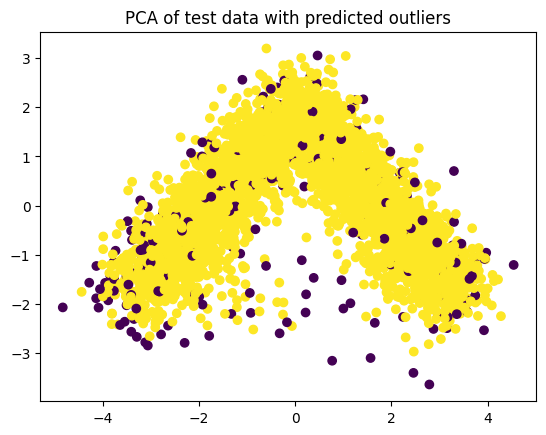

In [27]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=1 - pred)
plt.title("PCA of test data with predicted outliers")
plt.show()